In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [30]:
voting_df = pd.read_csv('./cache/voting_term10.csv')

In [31]:
voting_df.columns

Index(['id', 'date', 'sitting', 'sittingDay', 'votingNumber', 'title', 'topic',
       'description', 'kind', 'totalVoted', 'notParticipating', 'yes', 'no',
       'abstain', 'votingOptions', 'votes', 'percentOfYes', 'percentOfNo',
       'percentOfAbstain', 'percentOfAbsent'],
      dtype='object')

In [58]:
percent_column_regex = re.compile('percentOf')
percent_columns = [ x for x in voting_df.columns.to_list() if percent_column_regex.match(x) ]

In [64]:
voting_df[percent_columns].describe().drop('count', axis=0)

,percentOfYes,percentOfNo,percentOfAbstain,percentOfAbsent
mean,52.834501,42.547302,3.747552,6.614772
std,29.950139,29.203644,9.345740,4.332448
min,0.000000,0.000000,0.000000,0.220000
25%,41.460000,4.580000,0.000000,4.130000
50%,46.060000,52.550000,0.690000,6.090000
75%,60.530000,55.660000,3.630000,7.830000
max,100.000000,100.000000,58.240000,50.430000


In [65]:
voting_df[voting_df.percentOfAbsent == 50.43]

,id,date,sitting,sittingDay,votingNumber,title,topic,description,kind,totalVoted,notParticipating,yes,no,abstain,votingOptions,votes,percentOfYes,percentOfNo,percentOfAbstain,percentOfAbsent
884,885,2024-10-01T20:24:23,18,4,127,Pkt. 35 Zmiany w składach osobowych komisji se...,głosowanie nad przyjęciem wniosku z druku.,wniosek z druku nr 689,ELECTRONIC,227,232,221,5,1,NaN,"[{'MP': 1, 'club': 'PiS', 'firstName': 'Andrze...",97.36,2.2,0.44,50.43


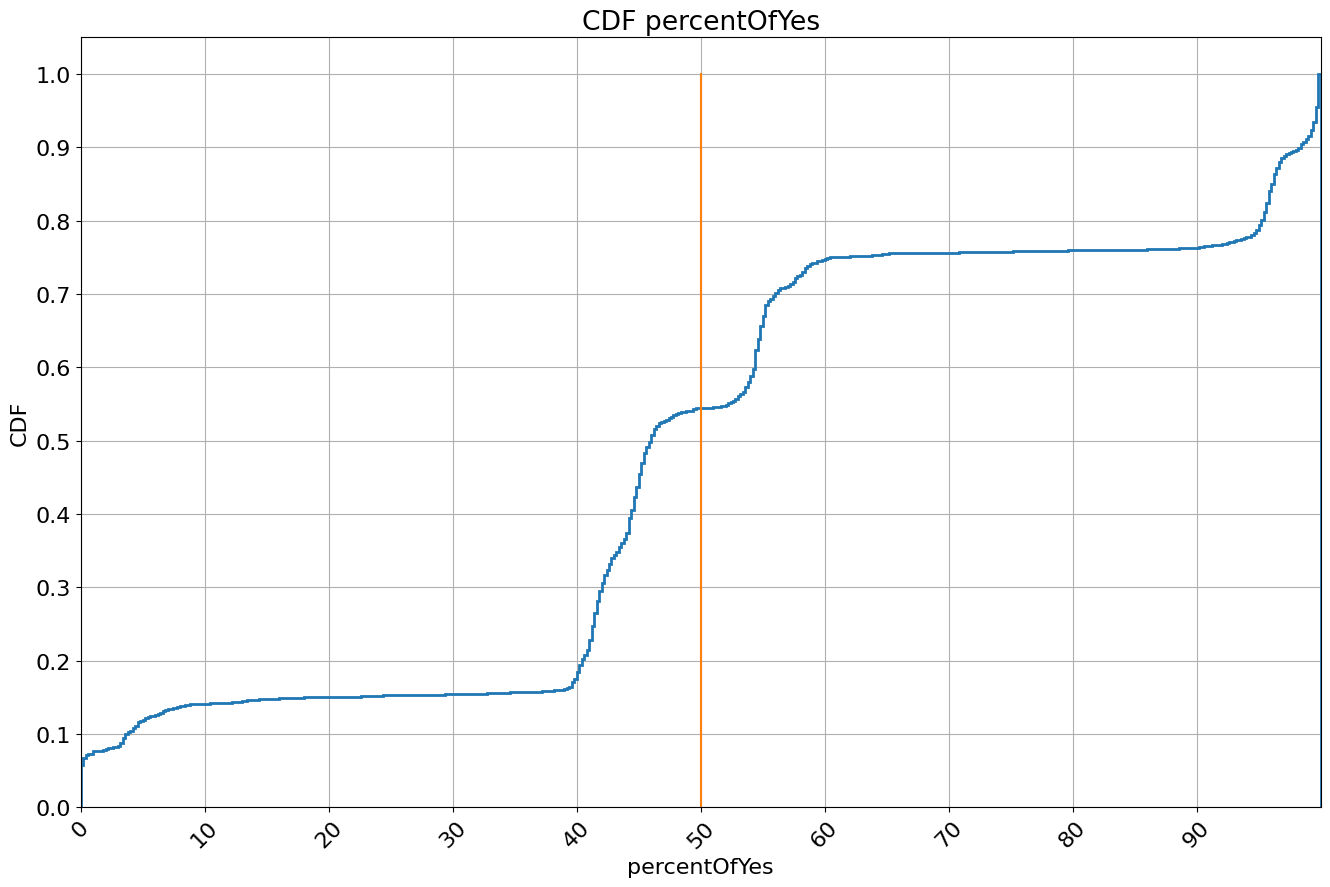

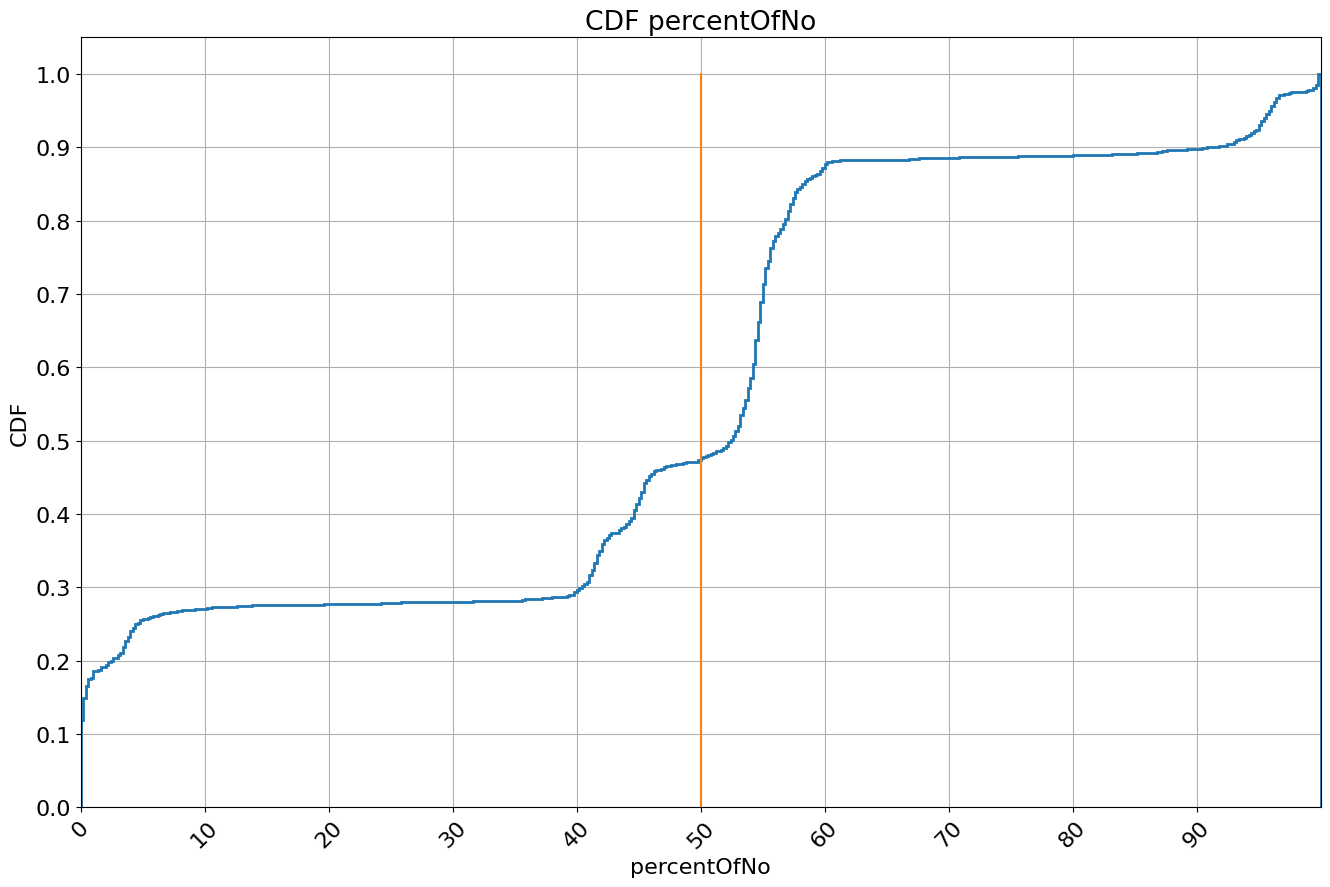

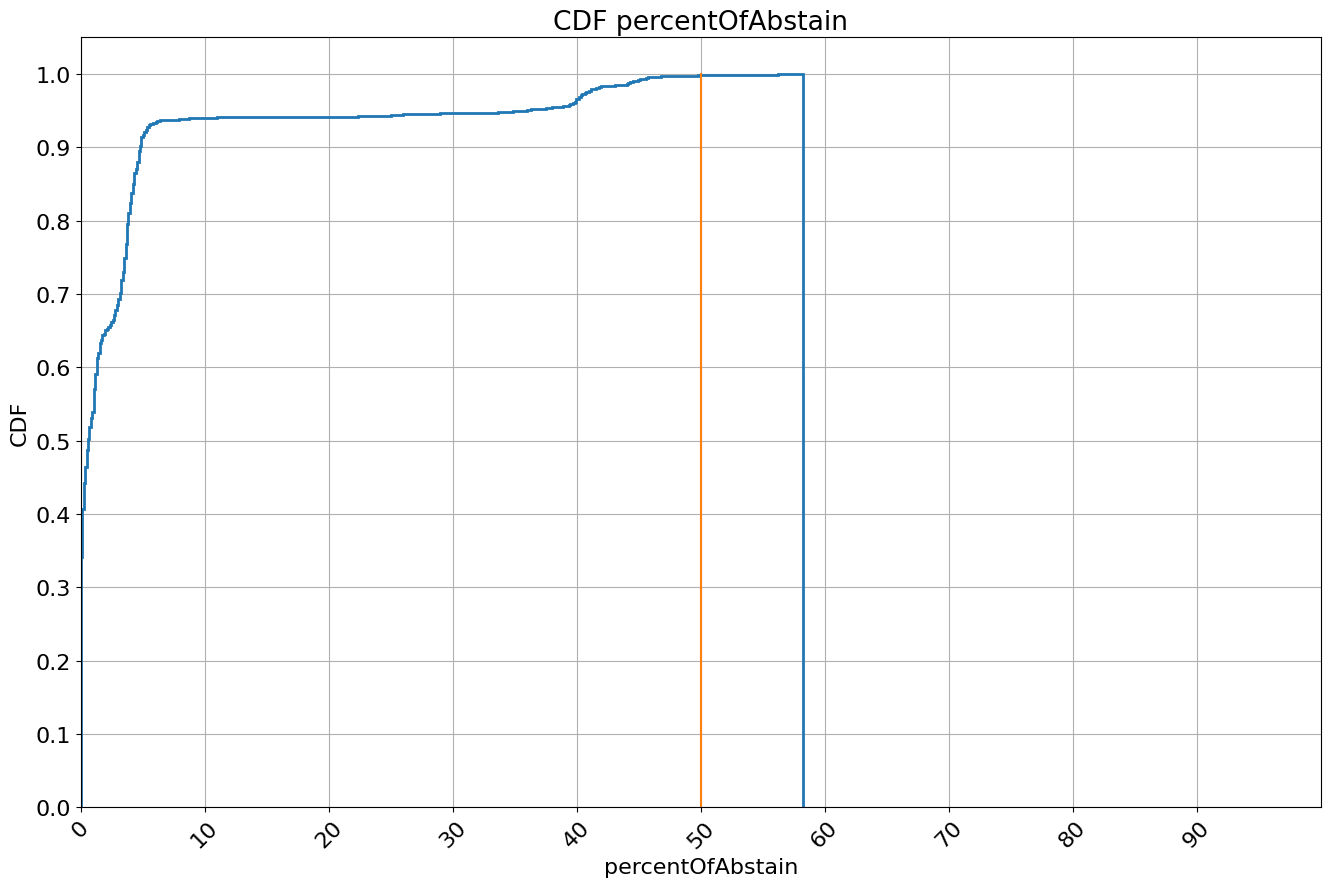

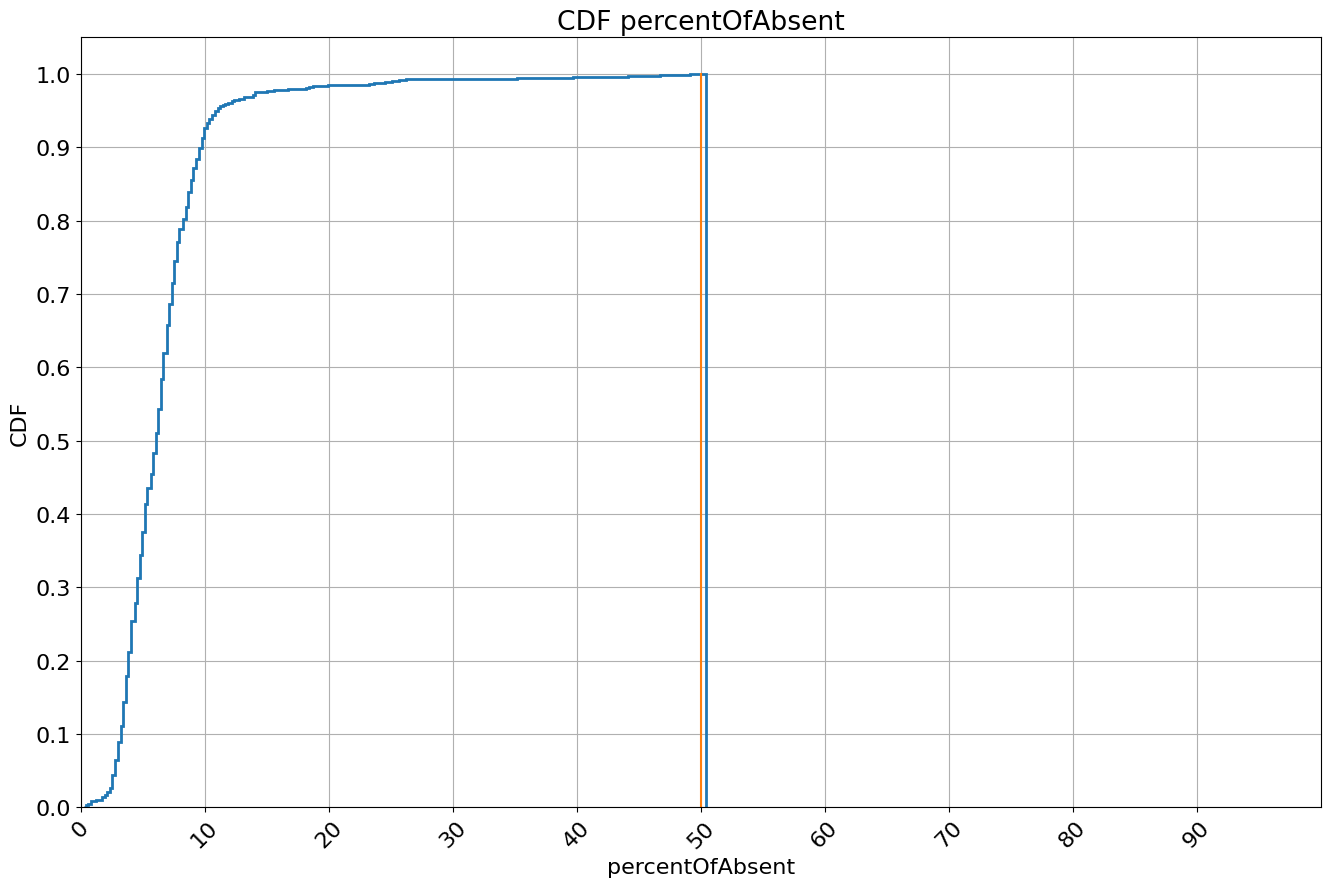

In [71]:
for column in percent_columns:
    plt.figure(figsize=(16,10))
    plt.rcParams.update(
        {'font.size': 16}
    )
    plt.hist(
        voting_df[column],
        bins=500,
        cumulative=True,
        density=True,
        histtype='step',
        linewidth=2
    )
    plt.plot([50,50], [0,1])
    plt.xticks(np.arange(0, 100, 10), np.arange(0, 100, 10), rotation=45)
    plt.yticks(np.arange(0, 1.1, 0.1), np.round(np.arange(0, 1.1, 0.1),1))
    plt.xlim(0,100)
    plt.grid(True)
    plt.title(f'CDF {column}')
    plt.xlabel(column)
    plt.ylabel('CDF')
    plt.show()